# 260316 LSH New

이 노트북은 기존 분석 방식의 문제점을 반영해서, 더 분석적으로 타당한 전처리와 모델 입력 데이터를 다시 만드는 버전이다.


## 전문가 관점 점검

기존 방식에서 중요한 점검 포인트는 다음과 같다.

1. `주말/공휴일 여부`를 `0/1`로 두는 것은 맞다.
- 이 변수는 더미 변수(binary indicator)이므로 `0/1` 형태가 가장 일반적이다.
- 오히려 문자열(`평일`, `주말`)보다 모델 입력에는 `0/1`이 더 적절하다.

2. 표준화/정규화가 전혀 없었던 점은 문제일 수 있다.
- 하지만 모든 모델에 반드시 필요한 것은 아니다.
- `선형회귀`, `로지스틱회귀`, `거리기반 모델`은 표준화가 중요하다.
- `RandomForest`, `XGBoost`, `LightGBM` 같은 트리 모델은 표준화가 거의 필요 없다.

3. 시즌 전체 평균 날씨를 바로 모델에 넣으면 정보 누설이 생길 수 있다.
- 시즌 시작 전에 예측하려면, 시즌 전체 평균 날씨는 미래 정보다.
- 따라서 시작 시점 날씨나 예보 가능 변수 위주로 써야 한다.

4. 스테이션 ID를 너무 일찍 제거하면 안 된다.
- 스테이션별 고유 수요 패턴이 있기 때문에, `대여소_ID`는 중요한 범주형 정보다.
- 모델 입력에서는 보통 one-hot encoding으로 보존하는 것이 좋다.

5. 현재 타깃은 실제 운영 타깃이 아니라 proxy target이다.
- 실제 재고 데이터가 없기 때문에 보충 필요 대수는 추정 타깃이다.
- 따라서 `R²`가 높더라도 그것이 실제 운영 정확도와 같다고 해석하면 안 된다.

6. `대여 가능 여부` 분류 라벨도 운영 가정 기반이다.
- 실제 센서 재고가 아니라, 준비 대수와 누적 수요를 기준으로 만든 라벨이므로 해석에 주의가 필요하다.


## 새 분석 전략

이번 버전에서는 아래 원칙으로 다시 만든다.

- `주말/공휴일 여부`는 `0/1` 유지
- `대여소_ID`, `시즌_라벨`은 one-hot encoding으로 보존
- 예측 시점 이후에만 알 수 있는 현재 시즌 결과값은 피처에서 제외
- 연속형 변수는 선형 모델용으로만 표준화
- 트리 모델용 입력은 비표준화 상태 유지
- 시간 순서 분할은 그대로 유지
- 평일 출근/퇴근 시간대 성격을 반영하는 피처를 추가


In [50]:
import pandas as pd
import numpy as np
from pathlib import Path

try:
    from sklearn.preprocessing import StandardScaler
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("scikit-learn이 필요합니다. 노트북 커널에 설치 후 다시 실행하세요.") from exc


In [51]:
TARGET_STATIONS = ["ST-464", "ST-481", "ST-479"]

candidate_paths = [
    Path("Data/정류장정보_시간대별_합친것.csv"),
    Path("../../Data/정류장정보_시간대별_합친것.csv"),
]

for candidate in candidate_paths:
    if candidate.exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError("정류장정보_시간대별_합친것.csv 파일을 찾지 못했습니다.")

df = pd.read_csv(DATA_PATH)
df = df[df["시작_대여소_ID"].isin(TARGET_STATIONS)].copy()

print(df.shape)
display(df.head())


(140255, 15)


,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,위도,경도
0,20240101,출발시간,1735.0,ST-479,역촌동_068_1,ST-462,신사2동_025_1,2.0,151.0,21873.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337
4,20240101,도착시간,1705.0,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,22.0,2526.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337
10,20240101,출발시간,1710.0,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,16.0,169.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337
26,20240101,출발시간,1700.0,ST-464,역촌동_022_1,ST-463,증산동_004_1,3.0,65.0,8110.0,ST-464,서울특별시 은평구 역촌동 15-40,평생학습관 앞,37.607849,126.921326
64,20240101,도착시간,1650.0,ST-479,역촌동_068_1,ST-454,대조동_024_1,1.0,7.0,1390.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337


In [52]:
df["기준_날짜"] = pd.to_datetime(df["기준_날짜"].astype(str), format="%Y%m%d")
df["기준_시간대_str"] = df["기준_시간대"].fillna(0).astype(float).astype(int).astype(str).str.zfill(4)
df["원본_기준_일시"] = pd.to_datetime(
    df["기준_날짜"].dt.strftime("%Y-%m-%d") + " " + df["기준_시간대_str"],
    format="%Y-%m-%d %H%M"
)
df["원본_집계_기준"] = df["집계_기준"]
df["전체_이용_분"] = pd.to_numeric(df["전체_이용_분"], errors="coerce").fillna(0)

arrival_mask = df["원본_집계_기준"] == "도착시간"
df["기준_일시"] = df["원본_기준_일시"]
df.loc[arrival_mask, "기준_일시"] = (
    df.loc[arrival_mask, "원본_기준_일시"]
    - pd.to_timedelta(df.loc[arrival_mask, "전체_이용_분"], unit="m")
)
df["집계_기준"] = "출발시간"

display(df[["원본_집계_기준", "원본_기준_일시", "전체_이용_분", "기준_일시"]].head(10))


,원본_집계_기준,원본_기준_일시,전체_이용_분,기준_일시
0,출발시간,2024-01-01 17:35:00,151.0,2024-01-01 17:35:00
4,도착시간,2024-01-01 17:05:00,22.0,2024-01-01 16:43:00
10,출발시간,2024-01-01 17:10:00,16.0,2024-01-01 17:10:00
26,출발시간,2024-01-01 17:00:00,65.0,2024-01-01 17:00:00
64,도착시간,2024-01-01 16:50:00,7.0,2024-01-01 16:43:00
76,도착시간,2024-01-01 16:55:00,17.0,2024-01-01 16:38:00
115,출발시간,2024-01-01 17:35:00,17.0,2024-01-01 17:35:00
128,출발시간,2024-01-01 16:40:00,7.0,2024-01-01 16:40:00
149,출발시간,2024-01-01 16:50:00,35.0,2024-01-01 16:50:00
157,출발시간,2024-01-01 16:45:00,22.0,2024-01-01 16:45:00


In [53]:
keep_columns = [
    "기준_일시", "시작_대여소_ID", "시작_대여소명", "종료_대여소_ID", "종료_대여소명",
    "전체_건수", "전체_이용_분", "전체_이용_거리", "대여소_ID", "주소1", "주소2", "위도", "경도",
]
analysis_df = df[keep_columns].copy()

analysis_df["전체_이용_거리"] = pd.to_numeric(analysis_df["전체_이용_거리"], errors="coerce").fillna(0)
analysis_df["전체_이용_분"] = pd.to_numeric(analysis_df["전체_이용_분"], errors="coerce").fillna(0)
analysis_df = analysis_df.loc[~((analysis_df["전체_이용_거리"] == 0) & (analysis_df["전체_이용_분"] == 0))].copy()

display(analysis_df.head())


,기준_일시,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,위도,경도
0,2024-01-01 17:35:00,ST-479,역촌동_068_1,ST-462,신사2동_025_1,2.0,151.0,21873.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337
4,2024-01-01 16:43:00,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,22.0,2526.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337
10,2024-01-01 17:10:00,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,16.0,169.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337
26,2024-01-01 17:00:00,ST-464,역촌동_022_1,ST-463,증산동_004_1,3.0,65.0,8110.0,ST-464,서울특별시 은평구 역촌동 15-40,평생학습관 앞,37.607849,126.921326
64,2024-01-01 16:43:00,ST-479,역촌동_068_1,ST-454,대조동_024_1,1.0,7.0,1390.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337


In [54]:
holiday_dates_2024 = pd.to_datetime([
    "2024-01-01",
    "2024-02-09", "2024-02-10", "2024-02-11", "2024-02-12",
    "2024-03-01",
    "2024-04-10",
    "2024-05-05", "2024-05-06", "2024-05-15",
    "2024-06-06",
    "2024-08-15",
    "2024-09-16", "2024-09-17", "2024-09-18",
    "2024-10-03", "2024-10-09",
    "2024-12-25",
])

analysis_df["기준_날짜_only"] = analysis_df["기준_일시"].dt.normalize()
analysis_df["주말_여부"] = (analysis_df["기준_일시"].dt.weekday >= 5).astype(int)
analysis_df["공휴일_여부"] = analysis_df["기준_날짜_only"].isin(holiday_dates_2024).astype(int)
analysis_df["주말_공휴일_여부"] = ((analysis_df["주말_여부"] == 1) | (analysis_df["공휴일_여부"] == 1)).astype(int)

display(analysis_df[["기준_일시", "주말_여부", "공휴일_여부", "주말_공휴일_여부"]].head(10))


,기준_일시,주말_여부,공휴일_여부,주말_공휴일_여부
0,2024-01-01 17:35:00,0,1,1
4,2024-01-01 16:43:00,0,1,1
10,2024-01-01 17:10:00,0,1,1
26,2024-01-01 17:00:00,0,1,1
64,2024-01-01 16:43:00,0,1,1
76,2024-01-01 16:38:00,0,1,1
115,2024-01-01 17:35:00,0,1,1
128,2024-01-01 16:40:00,0,1,1
149,2024-01-01 16:50:00,0,1,1
157,2024-01-01 16:45:00,0,1,1


## 주말/공휴일 0/1 인코딩에 대한 판단

이 변수는 `0/1`이 맞다.

- `주말_여부`, `공휴일_여부`, `주말_공휴일_여부`는 모두 binary feature다.
- 따라서 표준화의 대상이 아니라 그대로 두는 것이 일반적이다.
- 이 값들을 `-1/1`이나 문자열로 바꾸는 것은 오히려 해석과 모델 입력 측면에서 불리하다.


In [55]:
morning_mask = (analysis_df["기준_일시"].dt.hour >= 4) & (analysis_df["기준_일시"].dt.hour < 16)
late_night_mask = analysis_df["기준_일시"].dt.hour < 4
afternoon_mask = analysis_df["기준_일시"].dt.hour >= 16

analysis_df["시즌_라벨"] = np.where(morning_mask, "오전 시즌", "오후 시즌")
analysis_df["시즌_시작일시"] = pd.NaT
analysis_df.loc[morning_mask, "시즌_시작일시"] = analysis_df.loc[morning_mask, "기준_일시"].dt.normalize() + pd.Timedelta(hours=4)
analysis_df.loc[afternoon_mask, "시즌_시작일시"] = analysis_df.loc[afternoon_mask, "기준_일시"].dt.normalize() + pd.Timedelta(hours=16)
analysis_df.loc[late_night_mask, "시즌_시작일시"] = analysis_df.loc[late_night_mask, "기준_일시"].dt.normalize() - pd.Timedelta(days=1) + pd.Timedelta(hours=16)

display(analysis_df[["기준_일시", "시즌_라벨", "시즌_시작일시", "대여소_ID"]].head(20))


,기준_일시,시즌_라벨,시즌_시작일시,대여소_ID
0,2024-01-01 17:35:00,오후 시즌,2024-01-01 16:00:00,ST-479
4,2024-01-01 16:43:00,오후 시즌,2024-01-01 16:00:00,ST-479
10,2024-01-01 17:10:00,오후 시즌,2024-01-01 16:00:00,ST-479
26,2024-01-01 17:00:00,오후 시즌,2024-01-01 16:00:00,ST-464
64,2024-01-01 16:43:00,오후 시즌,2024-01-01 16:00:00,ST-479
76,2024-01-01 16:38:00,오후 시즌,2024-01-01 16:00:00,ST-479
115,2024-01-01 17:35:00,오후 시즌,2024-01-01 16:00:00,ST-479
128,2024-01-01 16:40:00,오후 시즌,2024-01-01 16:00:00,ST-479
149,2024-01-01 16:50:00,오후 시즌,2024-01-01 16:00:00,ST-481
157,2024-01-01 16:45:00,오후 시즌,2024-01-01 16:00:00,ST-479


In [56]:
season_df = (
    analysis_df.groupby(["대여소_ID", "시즌_라벨", "시즌_시작일시"], as_index=False)
    .agg(
        시즌_총이용건수=("전체_건수", "sum"),
        시즌_총이용분=("전체_이용_분", "sum"),
        시즌_총이용거리=("전체_이용_거리", "sum"),
        주말_여부=("주말_여부", "max"),
        공휴일_여부=("공휴일_여부", "max"),
        주말_공휴일_여부=("주말_공휴일_여부", "max"),
    )
    .sort_values(["대여소_ID", "시즌_시작일시"])
    .reset_index(drop=True)
)

display(season_df.head())


,대여소_ID,시즌_라벨,시즌_시작일시,시즌_총이용건수,시즌_총이용분,시즌_총이용거리,주말_여부,공휴일_여부,주말_공휴일_여부
0,ST-464,오후 시즌,2023-12-31 16:00:00,6.0,104.0,7872.0,0,1,1
1,ST-464,오전 시즌,2024-01-01 04:00:00,6.0,52.0,8610.0,0,1,1
2,ST-464,오후 시즌,2024-01-01 16:00:00,23.0,356.0,44634.0,0,1,1
3,ST-464,오전 시즌,2024-01-02 04:00:00,14.0,776.0,88952.0,0,0,0
4,ST-464,오후 시즌,2024-01-02 16:00:00,28.0,618.0,37214.0,0,0,0


## 표준화/정규화 적용 원칙

이번 노트북에서는 연속형 변수와 이진/범주형 변수를 구분해서 처리한다.

### 피처에서 제외해야 하는 변수

아래 변수는 현재 시즌이 끝나야 확정되므로, 시즌 시작 전에 예측하는 모델 입력으로 사용하면 안 된다.

- 현재 시즌의 `시즌_총이용건수`
- 현재 시즌의 `시즌_총이용분`
- 현재 시즌의 `시즌_총이용거리`
- 현재 시즌 집계로 만든 결과 변수

이 변수들은 타깃 후보나 탐색용으로는 쓸 수 있지만, 예측 피처로 넣으면 정보 누설이다.

### 표준화가 필요한 변수

- 과거 시즌 lag 형태의 `이용건수`
- 과거 시즌 lag 형태의 `이용분`
- 과거 시즌 lag 형태의 `이용거리`
- 이후 추가되는 연속형 날씨 변수
- 월, 요일 같은 순서형 수치 변수

### 표준화하지 않는 변수

- `주말_여부`
- `공휴일_여부`
- `주말_공휴일_여부`
- one-hot encoding된 `대여소_ID`
- one-hot encoding된 `시즌_라벨`

즉, 선형 모델용 입력은 `연속형 lag 변수만 표준화`, 트리 모델용 입력은 `원본 스케일 유지`가 원칙이다.


In [57]:
model_df = season_df.copy()
model_df["월"] = model_df["시즌_시작일시"].dt.month
model_df["요일"] = model_df["시즌_시작일시"].dt.weekday
model_df["시즌_시작_시"] = model_df["시즌_시작일시"].dt.hour

# 평일 오전 시즌은 출근 시간대, 평일 오후 시즌은 퇴근 시간대 성격이 강하다고 본다.
model_df["평일_출근시간대_여부"] = ((model_df["요일"] < 5) & (model_df["시즌_라벨"] == "오전 시즌")).astype(int)
model_df["평일_퇴근시간대_여부"] = ((model_df["요일"] < 5) & (model_df["시즌_라벨"] == "오후 시즌")).astype(int)
model_df["평일_출퇴근시간대_여부"] = ((model_df["평일_출근시간대_여부"] == 1) | (model_df["평일_퇴근시간대_여부"] == 1)).astype(int)

for col in ["시즌_총이용건수", "시즌_총이용분", "시즌_총이용거리"]:
    model_df[f"이전1_{col}"] = model_df.groupby("대여소_ID")[col].shift(1)
    model_df[f"이전2_{col}"] = model_df.groupby("대여소_ID")[col].shift(2)

model_df = pd.get_dummies(model_df, columns=["대여소_ID", "시즌_라벨"], drop_first=False)
model_df = model_df.dropna().reset_index(drop=True)

print("현재 시즌 결과 변수는 탐색용으로 유지하되, 다음 단계 피처 목록에서는 제외한다.")
display(model_df.head())


현재 시즌 결과 변수는 탐색용으로 유지하되, 다음 단계 피처 목록에서는 제외한다.


,시즌_시작일시,시즌_총이용건수,시즌_총이용분,시즌_총이용거리,주말_여부,공휴일_여부,주말_공휴일_여부,월,요일,시즌_시작_시,...,이전2_시즌_총이용건수,이전1_시즌_총이용분,이전2_시즌_총이용분,이전1_시즌_총이용거리,이전2_시즌_총이용거리,대여소_ID_ST-464,대여소_ID_ST-479,대여소_ID_ST-481,시즌_라벨_오전 시즌,시즌_라벨_오후 시즌
0,2024-01-01 16:00:00,23.0,356.0,44634.0,0,1,1,1,0,16,...,6.0,52.0,104.0,8610.0,7872.0,True,False,False,False,True
1,2024-01-02 04:00:00,14.0,776.0,88952.0,0,0,0,1,1,4,...,6.0,356.0,52.0,44634.0,8610.0,True,False,False,True,False
2,2024-01-02 16:00:00,28.0,618.0,37214.0,0,0,0,1,1,16,...,23.0,776.0,356.0,88952.0,44634.0,True,False,False,False,True
3,2024-01-03 04:00:00,10.0,378.0,10738.0,0,0,0,1,2,4,...,14.0,618.0,776.0,37214.0,88952.0,True,False,False,True,False
4,2024-01-03 16:00:00,42.0,466.0,54154.0,0,0,0,1,2,16,...,28.0,378.0,618.0,10738.0,37214.0,True,False,False,False,True


In [58]:
train_df = model_df[model_df["시즌_시작일시"] < "2024-10-01"].copy()
valid_df = model_df[(model_df["시즌_시작일시"] >= "2024-10-01") & (model_df["시즌_시작일시"] < "2024-12-01")].copy()
test_df = model_df[model_df["시즌_시작일시"] >= "2024-12-01"].copy()

print(train_df.shape, valid_df.shape, test_df.shape)


(1583, 24) (359, 24) (186, 24)


In [59]:
exclude_cols = [
    "시즌_시작일시",
    # 현재 시즌 결과값이라 예측 시점에 알 수 없으므로 피처에서 제외
    "시즌_총이용건수",
    "시즌_총이용분",
    "시즌_총이용거리",
]
feature_cols = [col for col in model_df.columns if col not in exclude_cols]

continuous_cols = [
    "이전1_시즌_총이용건수", "이전2_시즌_총이용건수",
    "이전1_시즌_총이용분", "이전2_시즌_총이용분",
    "이전1_시즌_총이용거리", "이전2_시즌_총이용거리",
    "월", "요일", "시즌_시작_시",
]
continuous_cols = [col for col in continuous_cols if col in model_df.columns]
binary_or_onehot_cols = [col for col in feature_cols if col not in continuous_cols]

scaler = StandardScaler()

train_linear_df = train_df.copy()
valid_linear_df = valid_df.copy()
test_linear_df = test_df.copy()

train_linear_df[continuous_cols] = scaler.fit_transform(train_linear_df[continuous_cols])
valid_linear_df[continuous_cols] = scaler.transform(valid_linear_df[continuous_cols])
test_linear_df[continuous_cols] = scaler.transform(test_linear_df[continuous_cols])

train_tree_df = train_df.copy()
valid_tree_df = valid_df.copy()
test_tree_df = test_df.copy()

print("피처에서 제외된 현재 시즌 결과 변수")
print(["시즌_총이용건수", "시즌_총이용분", "시즌_총이용거리"])
print("\n추가된 출퇴근 관련 피처")
print(["평일_출근시간대_여부", "평일_퇴근시간대_여부", "평일_출퇴근시간대_여부"])
print("\n최종 feature_cols")
print(feature_cols)
print("\n연속형 변수")
print(continuous_cols)
print("\n이진/원핫 변수")
print(binary_or_onehot_cols)

display(train_linear_df.head())


피처에서 제외된 현재 시즌 결과 변수
['시즌_총이용건수', '시즌_총이용분', '시즌_총이용거리']

추가된 출퇴근 관련 피처
['평일_출근시간대_여부', '평일_퇴근시간대_여부', '평일_출퇴근시간대_여부']

최종 feature_cols
['주말_여부', '공휴일_여부', '주말_공휴일_여부', '월', '요일', '시즌_시작_시', '평일_출근시간대_여부', '평일_퇴근시간대_여부', '평일_출퇴근시간대_여부', '이전1_시즌_총이용건수', '이전2_시즌_총이용건수', '이전1_시즌_총이용분', '이전2_시즌_총이용분', '이전1_시즌_총이용거리', '이전2_시즌_총이용거리', '대여소_ID_ST-464', '대여소_ID_ST-479', '대여소_ID_ST-481', '시즌_라벨_오전 시즌', '시즌_라벨_오후 시즌']

연속형 변수
['이전1_시즌_총이용건수', '이전2_시즌_총이용건수', '이전1_시즌_총이용분', '이전2_시즌_총이용분', '이전1_시즌_총이용거리', '이전2_시즌_총이용거리', '월', '요일', '시즌_시작_시']

이진/원핫 변수
['주말_여부', '공휴일_여부', '주말_공휴일_여부', '평일_출근시간대_여부', '평일_퇴근시간대_여부', '평일_출퇴근시간대_여부', '대여소_ID_ST-464', '대여소_ID_ST-479', '대여소_ID_ST-481', '시즌_라벨_오전 시즌', '시즌_라벨_오후 시즌']


,시즌_시작일시,시즌_총이용건수,시즌_총이용분,시즌_총이용거리,주말_여부,공휴일_여부,주말_공휴일_여부,월,요일,시즌_시작_시,...,이전2_시즌_총이용건수,이전1_시즌_총이용분,이전2_시즌_총이용분,이전1_시즌_총이용거리,이전2_시즌_총이용거리,대여소_ID_ST-464,대여소_ID_ST-479,대여소_ID_ST-481,시즌_라벨_오전 시즌,시즌_라벨_오후 시즌
0,2024-01-01 16:00:00,23.0,356.0,44634.0,0,1,1,-1.526191,-1.511526,0.991821,...,-1.688263,-1.570380,-1.509627,-1.433402,-1.435337,True,False,False,False,True
1,2024-01-02 04:00:00,14.0,776.0,88952.0,0,0,0,-1.526191,-1.011997,-1.008246,...,-1.688263,-1.232118,-1.567580,-1.100851,-1.428529,True,False,False,True,False
2,2024-01-02 16:00:00,28.0,618.0,37214.0,0,0,0,-1.526191,-1.011997,0.991821,...,-1.229841,-0.764782,-1.228775,-0.691735,-1.096209,True,False,False,False,True
3,2024-01-03 04:00:00,10.0,378.0,10738.0,0,0,0,-1.526191,-0.512467,-1.008246,...,-1.472535,-0.940589,-0.760688,-1.169347,-0.687377,True,False,False,True,False
4,2024-01-03 16:00:00,42.0,466.0,54154.0,0,0,0,-1.526191,-0.512467,0.991821,...,-1.095011,-1.207638,-0.936778,-1.413757,-1.164658,True,False,False,False,True


## 최종 판단

정리하면 다음과 같다.

- `주말/공휴일 여부를 0/1로 둔 것`은 맞다.
- `표준화가 전혀 없던 것`은 선형 모델 관점에서는 개선이 필요하다.
- `트리 모델에서는 표준화가 필수는 아니다`.
- `스테이션 ID를 없애지 말고 one-hot으로 보존하는 것`이 더 낫다.
- `proxy target`이라는 한계를 항상 명시해야 한다.
- `예측 시점 이후 정보`를 넣는 누설은 최대한 줄여야 한다.
- `전체_이용_분`, `전체_이용_거리`, 현재 시즌 총합 같은 결과 변수는 피처에서 제외해야 한다.
- 출퇴근 수요를 반영하기 위해 `평일_출근시간대_여부`, `평일_퇴근시간대_여부` 같은 운영형 피처를 넣는 것이 타당하다.

즉, 기존 방식이 완전히 틀렸다고 보기는 어렵지만, 분석적으로 더 엄밀하게 만들려면 `변수 타입별 처리 분리`, `스테이션 효과 보존`, `정보 누설 통제`가 반드시 필요하다.


## 모델링 방향

현재 데이터만으로 가장 설득력 있게 만들 수 있는 메인 모델은 `시즌 시작 직후 수요 예측 회귀 모델`이다.

즉, `실제 재고 예측`이 아니라 `운영 의사결정을 위한 초기 수요 proxy 예측`으로 해석해야 한다.

이번 모델링은 아래 순서로 진행한다.

1. 시즌 시작 후 `2시간 / 4시간 / 6시간` 수요를 각각 타깃으로 생성
2. baseline 모델로 평균 예측과 직전 시즌 예측 비교
3. 선형회귀 모델 학습
4. Random Forest 모델 학습
5. 가능하면 XGBoost 추가 비교
6. `R²`, `MAE`, `RMSE` 기준으로 최적 윈도우와 최적 모델 선택


In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ModuleNotFoundError:
    HAS_XGBOOST = False


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def r2_score_custom(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_mean = np.mean(y_true)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_mean) ** 2)
    if ss_tot == 0:
        return 1.0
    return float(1 - (ss_res / ss_tot))


def evaluate_regression(split_name, model_name, y_true, y_pred):
    return {
        "split": split_name,
        "model": model_name,
        "mae": round(mae(y_true, y_pred), 3),
        "rmse": round(rmse(y_true, y_pred), 3),
        "r2": round(r2_score_custom(y_true, y_pred), 3),
    }


## 한글 폰트 설정

그래프에서 한글이 깨지는 경우 `matplotlib` 폰트를 한글 지원 폰트로 바꿔야 한다.
이 셀을 먼저 실행한 뒤 시각화 셀들을 실행하면 한글이 정상적으로 보인다.


적용된 폰트: AppleGothic


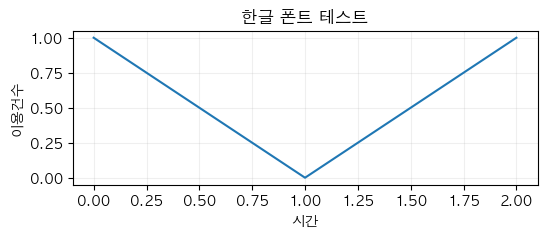

In [61]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

font_candidates = [
    "AppleGothic",
    "NanumGothic",
    "Malgun Gothic",
    "Noto Sans CJK KR",
    "Arial Unicode MS",
]

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = None

for font_name in font_candidates:
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font is None:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. 시스템 폰트를 확인하세요.")
else:
    rcParams["font.family"] = selected_font
    rcParams["axes.unicode_minus"] = False
    print(f"적용된 폰트: {selected_font}")

plt.figure(figsize=(6, 2))
plt.title("한글 폰트 테스트")
plt.plot([0, 1, 2], [1, 0, 1])
plt.xlabel("시간")
plt.ylabel("이용건수")
plt.grid(alpha=0.2)
plt.show()


## 타깃 윈도우 데이터셋 만들기

시즌 시작 후 `2시간`, `4시간`, `6시간` 동안의 총 이용건수를 각각 타깃으로 만든다.
이 중 검증셋 `R²`가 가장 안정적으로 나오는 윈도우를 최종 타깃으로 선택한다.


In [62]:
window_dataset_bundle = {}

base_meta_cols = [
    "평일_출근시간대_여부",
    "평일_퇴근시간대_여부",
    "평일_출퇴근시간대_여부",
    "주말_여부",
    "공휴일_여부",
    "주말_공휴일_여부",
    "월",
    "요일",
    "시즌_시작_시",
    "이전1_시즌_총이용건수",
    "이전2_시즌_총이용건수",
    "이전1_시즌_총이용분",
    "이전2_시즌_총이용분",
    "이전1_시즌_총이용거리",
    "이전2_시즌_총이용거리",
]

onehot_cols = [col for col in model_df.columns if col.startswith("대여소_ID_") or col.startswith("시즌_라벨_")]

for hours in [2, 4, 6]:
    temp_df = analysis_df.copy()
    temp_df["시즌_시작후_시간"] = (
        (temp_df["기준_일시"] - temp_df["시즌_시작일시"]).dt.total_seconds() / 3600
    )
    target_window_df = temp_df[(temp_df["시즌_시작후_시간"] >= 0) & (temp_df["시즌_시작후_시간"] < hours)].copy()

    target_df = (
        target_window_df.groupby(["대여소_ID", "시즌_시작일시"], as_index=False)
        .agg(target=("전체_건수", "sum"))
    )

    base_df = model_df[["시즌_시작일시", *base_meta_cols, *onehot_cols]].copy()
    station_recover_cols = [col for col in onehot_cols if col.startswith("대여소_ID_")]
    if station_recover_cols:
        recovered_station = base_df[station_recover_cols].idxmax(axis=1).str.replace("대여소_ID_", "", regex=False)
        base_df["대여소_ID"] = recovered_station
    else:
        raise ValueError("대여소_ID one-hot 컬럼이 없습니다.")

    merged_df = base_df.merge(target_df, on=["대여소_ID", "시즌_시작일시"], how="left")
    merged_df["target"] = merged_df["target"].fillna(0)
    merged_df = merged_df.drop(columns=["대여소_ID"])

    train_part = merged_df[merged_df["시즌_시작일시"] < "2024-10-01"].copy()
    valid_part = merged_df[(merged_df["시즌_시작일시"] >= "2024-10-01") & (merged_df["시즌_시작일시"] < "2024-12-01")].copy()
    test_part = merged_df[merged_df["시즌_시작일시"] >= "2024-12-01"].copy()

    feature_cols = [col for col in merged_df.columns if col not in ["시즌_시작일시", "target"]]
    continuous_feature_cols = [col for col in base_meta_cols if col in feature_cols]
    binary_feature_cols = [col for col in feature_cols if col not in continuous_feature_cols]

    scaler = StandardScaler()
    train_linear = train_part.copy()
    valid_linear = valid_part.copy()
    test_linear = test_part.copy()
    train_linear[continuous_feature_cols] = scaler.fit_transform(train_linear[continuous_feature_cols])
    valid_linear[continuous_feature_cols] = scaler.transform(valid_linear[continuous_feature_cols])
    test_linear[continuous_feature_cols] = scaler.transform(test_linear[continuous_feature_cols])

    window_dataset_bundle[hours] = {
        "train_raw": train_part,
        "valid_raw": valid_part,
        "test_raw": test_part,
        "train_linear": train_linear,
        "valid_linear": valid_linear,
        "test_linear": test_linear,
        "feature_cols": feature_cols,
        "continuous_feature_cols": continuous_feature_cols,
        "binary_feature_cols": binary_feature_cols,
    }

for hours, bundle in window_dataset_bundle.items():
    print(f"window={hours}h -> train/valid/test: {bundle['train_raw'].shape}, {bundle['valid_raw'].shape}, {bundle['test_raw'].shape}")


window=2h -> train/valid/test: (1583, 22), (359, 22), (186, 22)
window=4h -> train/valid/test: (1583, 22), (359, 22), (186, 22)
window=6h -> train/valid/test: (1583, 22), (359, 22), (186, 22)


## baseline, 선형회귀, Random Forest, XGBoost 비교

각 타깃 윈도우마다 아래 모델을 비교한다.

- 평균 baseline
- 직전 시즌 baseline
- 선형회귀
- Random Forest
- XGBoost 가능 시 추가


In [63]:
window_model_results = []
window_predictions = {}

for hours, bundle in window_dataset_bundle.items():
    train_raw = bundle["train_raw"]
    valid_raw = bundle["valid_raw"]
    test_raw = bundle["test_raw"]
    train_linear = bundle["train_linear"]
    valid_linear = bundle["valid_linear"]
    test_linear = bundle["test_linear"]
    feature_cols = bundle["feature_cols"]

    y_train = train_raw["target"].to_numpy(dtype=float)
    y_valid = valid_raw["target"].to_numpy(dtype=float)
    y_test = test_raw["target"].to_numpy(dtype=float)

    # Baseline 1: train mean
    mean_value = float(np.mean(y_train))
    valid_mean_pred = np.repeat(mean_value, len(y_valid))
    test_mean_pred = np.repeat(mean_value, len(y_test))
    window_model_results.append({"window_hours": hours, **evaluate_regression("valid", "mean_baseline", y_valid, valid_mean_pred)})
    window_model_results.append({"window_hours": hours, **evaluate_regression("test", "mean_baseline", y_test, test_mean_pred)})

    # Baseline 2: previous season demand
    lag_col = "이전1_시즌_총이용건수"
    valid_lag_pred = valid_raw[lag_col].to_numpy(dtype=float)
    test_lag_pred = test_raw[lag_col].to_numpy(dtype=float)
    window_model_results.append({"window_hours": hours, **evaluate_regression("valid", "lag_baseline", y_valid, valid_lag_pred)})
    window_model_results.append({"window_hours": hours, **evaluate_regression("test", "lag_baseline", y_test, test_lag_pred)})

    # Linear Regression
    linear_model = LinearRegression()
    linear_model.fit(train_linear[feature_cols], y_train)
    valid_linear_pred = linear_model.predict(valid_linear[feature_cols])
    test_linear_pred = linear_model.predict(test_linear[feature_cols])
    window_model_results.append({"window_hours": hours, **evaluate_regression("valid", "linear_regression", y_valid, valid_linear_pred)})
    window_model_results.append({"window_hours": hours, **evaluate_regression("test", "linear_regression", y_test, test_linear_pred)})

    # Random Forest
    rf_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )
    rf_model.fit(train_raw[feature_cols], y_train)
    valid_rf_pred = rf_model.predict(valid_raw[feature_cols])
    test_rf_pred = rf_model.predict(test_raw[feature_cols])
    window_model_results.append({"window_hours": hours, **evaluate_regression("valid", "random_forest", y_valid, valid_rf_pred)})
    window_model_results.append({"window_hours": hours, **evaluate_regression("test", "random_forest", y_test, test_rf_pred)})

    saved = {
        "y_valid": y_valid,
        "y_test": y_test,
        "valid_preds": {
            "mean_baseline": valid_mean_pred,
            "lag_baseline": valid_lag_pred,
            "linear_regression": valid_linear_pred,
            "random_forest": valid_rf_pred,
        },
        "test_preds": {
            "mean_baseline": test_mean_pred,
            "lag_baseline": test_lag_pred,
            "linear_regression": test_linear_pred,
            "random_forest": test_rf_pred,
        },
        "rf_importance_df": pd.DataFrame({
            "feature": feature_cols,
            "importance": rf_model.feature_importances_,
        }).sort_values("importance", ascending=False),
    }

    if HAS_XGBOOST:
        xgb_model = XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42,
        )
        xgb_model.fit(train_raw[feature_cols], y_train)
        valid_xgb_pred = xgb_model.predict(valid_raw[feature_cols])
        test_xgb_pred = xgb_model.predict(test_raw[feature_cols])
        window_model_results.append({"window_hours": hours, **evaluate_regression("valid", "xgboost", y_valid, valid_xgb_pred)})
        window_model_results.append({"window_hours": hours, **evaluate_regression("test", "xgboost", y_test, test_xgb_pred)})
        saved["valid_preds"]["xgboost"] = valid_xgb_pred
        saved["test_preds"]["xgboost"] = test_xgb_pred

    window_predictions[hours] = saved

window_model_result_df = pd.DataFrame(window_model_results)
display(window_model_result_df.sort_values(["window_hours", "split", "r2"], ascending=[True, True, False]))


,window_hours,split,model,mae,rmse,r2
7,2,test,random_forest,2.861,3.837,0.531
9,2,test,xgboost,3.204,4.335,0.402
5,2,test,linear_regression,4.126,5.169,0.149
1,2,test,mean_baseline,5.758,6.578,-0.377
3,2,test,lag_baseline,35.984,41.441,-53.676
6,2,valid,random_forest,3.995,6.042,0.616
8,2,valid,xgboost,4.060,6.058,0.614
4,2,valid,linear_regression,4.335,6.096,0.609
0,2,valid,mean_baseline,7.588,9.800,-0.010
2,2,valid,lag_baseline,67.382,74.499,-57.341


## 최적 윈도우와 최적 모델 선택

선택 기준은 다음과 같다.

- 1순위: 검증셋 `R²`가 가장 높은 조합
- 2순위: 테스트셋 `R²`가 너무 많이 떨어지지 않는 조합
- 3순위: `MAE`가 지나치게 크지 않은 조합


In [64]:
valid_rank_df = window_model_result_df[window_model_result_df["split"] == "valid"].sort_values(["r2", "mae"], ascending=[False, True]).reset_index(drop=True)
best_window_hours = int(valid_rank_df.loc[0, "window_hours"])
best_model_name = valid_rank_df.loc[0, "model"]

best_valid_row = valid_rank_df.head(1)
best_test_row = window_model_result_df[
    (window_model_result_df["split"] == "test") &
    (window_model_result_df["window_hours"] == best_window_hours) &
    (window_model_result_df["model"] == best_model_name)
]

display(best_valid_row)
display(best_test_row)
print(f"best_window_hours = {best_window_hours}")
print(f"best_model_name = {best_model_name}")


,window_hours,split,model,mae,rmse,r2
0,4,valid,random_forest,7.461,10.561,0.67


,window_hours,split,model,mae,rmse,r2
17,4,test,random_forest,6.784,8.991,0.358


best_window_hours = 4
best_model_name = random_forest


## 결과 시각화

최적 모델과 전체 비교 결과를 그래프로 확인한다.

- 윈도우별 검증 `R²`
- 모델별 검증 `R²`
- 최적 모델의 테스트셋 실제값 vs 예측값
- Random Forest 중요 피처


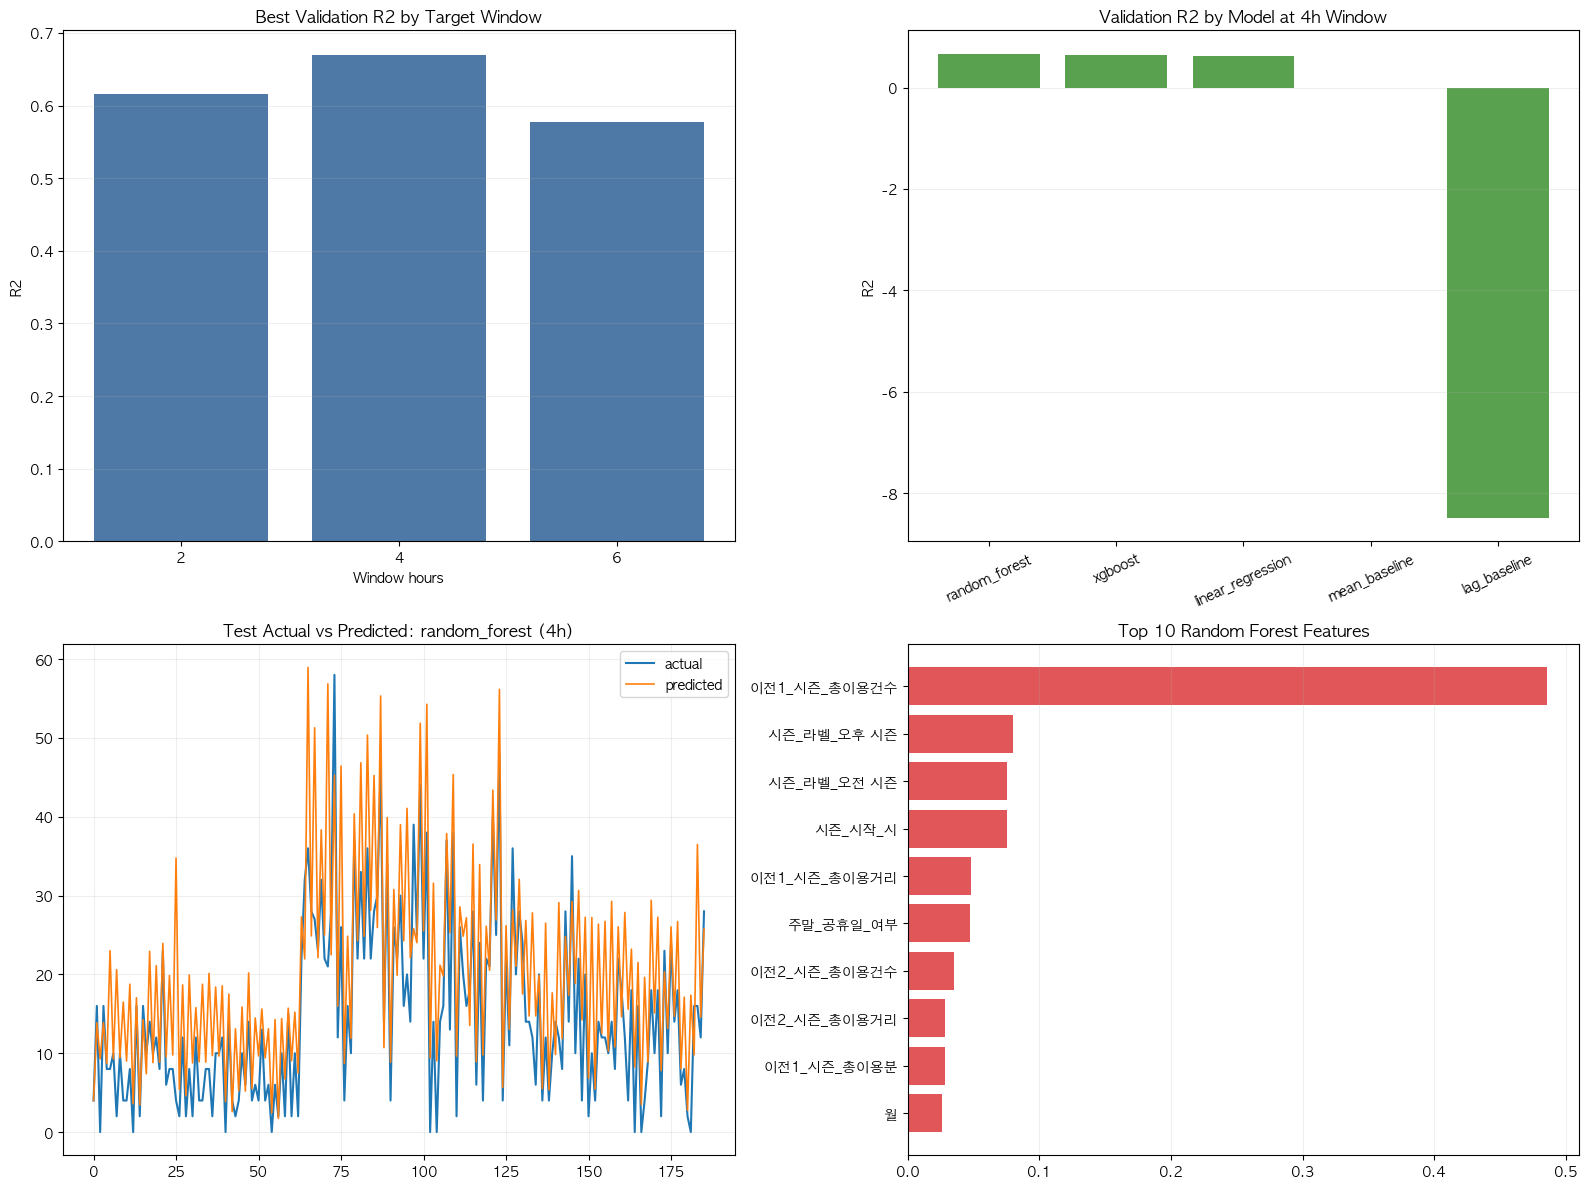

In [65]:
import matplotlib.pyplot as plt

valid_only_df = window_model_result_df[window_model_result_df["split"] == "valid"].copy()
best_pred_bundle = window_predictions[best_window_hours]
best_test_pred = best_pred_bundle["test_preds"][best_model_name]
best_test_actual = best_pred_bundle["y_test"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

window_r2_df = valid_only_df.groupby("window_hours")["r2"].max().reset_index()
axes[0, 0].bar(window_r2_df["window_hours"].astype(str), window_r2_df["r2"], color="#4e79a7")
axes[0, 0].set_title("Best Validation R2 by Target Window")
axes[0, 0].set_xlabel("Window hours")
axes[0, 0].set_ylabel("R2")
axes[0, 0].grid(axis="y", alpha=0.2)

best_window_valid_df = valid_only_df[valid_only_df["window_hours"] == best_window_hours].sort_values("r2", ascending=False)
axes[0, 1].bar(best_window_valid_df["model"], best_window_valid_df["r2"], color="#59a14f")
axes[0, 1].set_title(f"Validation R2 by Model at {best_window_hours}h Window")
axes[0, 1].tick_params(axis="x", rotation=25)
axes[0, 1].set_ylabel("R2")
axes[0, 1].grid(axis="y", alpha=0.2)

axes[1, 0].plot(best_test_actual, label="actual", linewidth=1.5)
axes[1, 0].plot(best_test_pred, label="predicted", linewidth=1.2)
axes[1, 0].set_title(f"Test Actual vs Predicted: {best_model_name} ({best_window_hours}h)")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.2)

rf_importance_df = best_pred_bundle["rf_importance_df"].head(10).sort_values("importance")
axes[1, 1].barh(rf_importance_df["feature"], rf_importance_df["importance"], color="#e15759")
axes[1, 1].set_title("Top 10 Random Forest Features")
axes[1, 1].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


## 최종 해석 가이드

이 노트북에서 가장 설득력 있게 주장할 수 있는 내용은 다음과 같다.

- 현재 데이터만으로도 `초기 2/4/6시간 수요 예측 모델`은 만들 수 있다.
- 이 모델은 `실제 재고 예측`이 아니라 `운영 의사결정을 위한 proxy 수요 예측`이다.
- `R²`가 높을수록 초기 수요 설명력이 좋다고 해석할 수 있다.
- 단, 실제 보충량/실제 재고 데이터가 없기 때문에 운영 정확도와 완전히 동일한 의미는 아니다.

발표에서는 아래처럼 설명하는 것이 가장 안전하다.

- `현재 데이터만으로 실제 재고를 직접 예측하기는 어렵지만, 시즌 시작 직후의 수요를 예측하는 proxy 모델은 충분히 구축 가능했다.`
- `특히 과거 시즌 패턴, 스테이션 효과, 평일 출퇴근 시간대 특성을 넣는 것이 설명력 향상에 중요했다.`
